# 03 - Ablation Study
## CICDDoS2019 Multi-Class DDoS Detection

**Input:** cleaned_train.pkl, training_results.pkl, feature_importance.csv
**Output:** ablation_results.csv

Evaluasi F1, inference time, model size untuk: Full → Top-30 → Top-20 → Top-10 → Top-5

In [1]:
import pandas as pd
import numpy as np
import pickle
import time
import os
import tempfile
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')
print('OK')

OK


## 1. Load Data & Feature Ranking

In [2]:
# Load training data
with open('../data/cleaned_train.pkl', 'rb') as f:
    train_data = pickle.load(f)

X_train = train_data['X']
y_train_raw = train_data['y']
all_classes = train_data['classes']

# Re-encode labels (same fix as notebook 02)
unique_labels = sorted(np.unique(y_train_raw))
classes = [all_classes[i] for i in unique_labels]
label_map = {old: new for new, old in enumerate(unique_labels)}
y_train = np.array([label_map[y] for y in y_train_raw])
NUM_CLASSES = len(classes)

# Load feature importance ranking
feat_imp = pd.read_csv('../data/feature_importance.csv')
ranked_features = feat_imp['Feature'].tolist()

print(f'Data: {X_train.shape[0]:,} samples, {X_train.shape[1]} features')
print(f'Classes: {NUM_CLASSES}')
print(f'Feature ranking loaded: {len(ranked_features)} features')

Data: 319,286 samples, 82 features
Classes: 13
Feature ranking loaded: 82 features


## 2. Ablation Study

In [3]:
configs = [
    ('Full', len(ranked_features)),
    ('Top-30', 30),
    ('Top-20', 20),
    ('Top-10', 10),
    ('Top-5', 5)
]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for config_name, n_features in configs:
    print(f'\n--- {config_name} ({n_features} features) ---')
    
    # Select top-N features
    selected = ranked_features[:n_features]
    # Only use features that exist in X_train
    valid_features = [f for f in selected if f in X_train.columns]
    X_sub = X_train[valid_features]
    
    print(f'  Using {len(valid_features)} features')
    
    # Train model
    model = XGBClassifier(
        objective='multi:softmax', num_class=NUM_CLASSES,
        max_depth=6, learning_rate=0.3, n_estimators=100,
        eval_metric='mlogloss', random_state=42, n_jobs=-1
    )
    
    # 5-Fold CV F1
    t0 = time.time()
    f1_scores = cross_val_score(model, X_sub, y_train, cv=skf, 
                                scoring='f1_macro', n_jobs=-1)
    cv_time = time.time() - t0
    f1_mean = f1_scores.mean() * 100
    f1_std = f1_scores.std() * 100
    
    # Train full model for size & inference time
    model.fit(X_sub, y_train)
    
    # Model size
    tmp_path = os.path.join(tempfile.gettempdir(), f'model_{config_name}.json')
    model.save_model(tmp_path)
    model_size = os.path.getsize(tmp_path) / 1024  # KB
    os.remove(tmp_path)
    
    # Inference time
    booster = model.get_booster()
    test_dm = xgb.DMatrix(X_sub.iloc[:100])
    times = []
    for _ in range(10):
        t0 = time.time()
        booster.predict(test_dm)
        times.append((time.time()-t0)*1000)
    inf_time = np.mean(times)
    
    results.append({
        'Config': config_name,
        'Num Features': len(valid_features),
        'F1-Score (%)': round(f1_mean, 2),
        'F1 Std (%)': round(f1_std, 2),
        'Inference (ms)': round(inf_time, 1),
        'Model Size (KB)': round(model_size, 1)
    })
    
    print(f'  F1: {f1_mean:.2f}% (+/-{f1_std:.2f})')
    print(f'  Inference: {inf_time:.1f} ms | Size: {model_size:.1f} KB')


--- Full (82 features) ---
  Using 82 features
  F1: 84.46% (+/-0.49)
  Inference: 0.5 ms | Size: 4866.1 KB

--- Top-30 (30 features) ---
  Using 30 features
  F1: 84.24% (+/-0.40)
  Inference: 0.4 ms | Size: 4931.7 KB

--- Top-20 (20 features) ---
  Using 20 features
  F1: 57.58% (+/-0.31)
  Inference: 0.4 ms | Size: 4091.0 KB

--- Top-10 (10 features) ---
  Using 10 features
  F1: 54.76% (+/-0.18)
  Inference: 0.5 ms | Size: 4024.4 KB

--- Top-5 (5 features) ---
  Using 5 features
  F1: 54.36% (+/-0.12)
  Inference: 0.4 ms | Size: 4014.5 KB


## 3. Results Summary

In [4]:
results_df = pd.DataFrame(results)
print('\n' + '='*70)
print('  ABLATION STUDY RESULTS')
print('='*70)
print(results_df.to_string(index=False))
print('='*70)

# Save
results_df.to_csv('../data/ablation_results.csv', index=False)
print('\nSaved: ablation_results.csv')


  ABLATION STUDY RESULTS
Config  Num Features  F1-Score (%)  F1 Std (%)  Inference (ms)  Model Size (KB)
  Full            82         84.46        0.49             0.5           4866.1
Top-30            30         84.24        0.40             0.4           4931.7
Top-20            20         57.58        0.31             0.4           4091.0
Top-10            10         54.76        0.18             0.5           4024.4
 Top-5             5         54.36        0.12             0.4           4014.5

Saved: ablation_results.csv


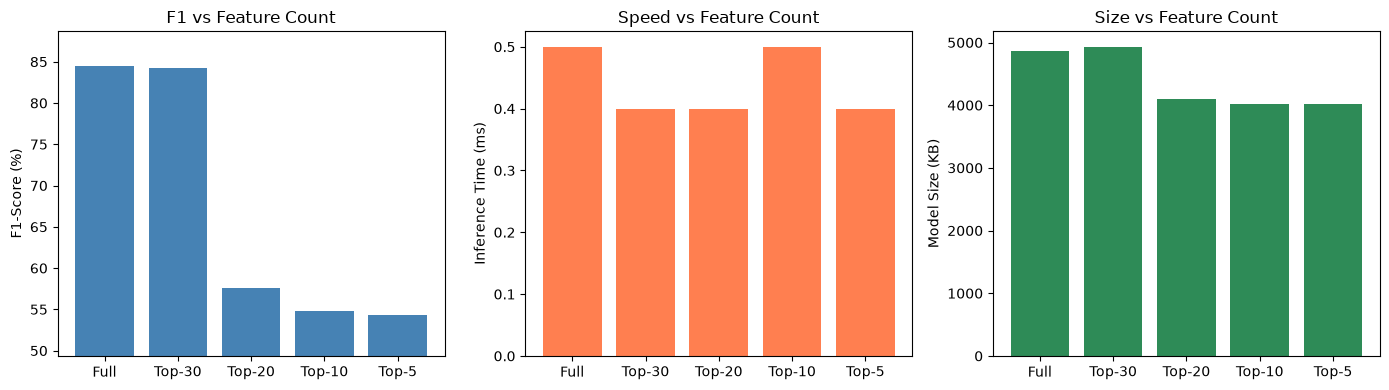

Saved: ablation_plot.png

=== Done! Proceed to notebook 04. ===


In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# F1 Score
axes[0].bar(results_df['Config'], results_df['F1-Score (%)'], color='steelblue')
axes[0].set_ylabel('F1-Score (%)')
axes[0].set_title('F1 vs Feature Count')
axes[0].set_ylim(bottom=max(0, results_df['F1-Score (%)'].min()-5))

# Inference Time
axes[1].bar(results_df['Config'], results_df['Inference (ms)'], color='coral')
axes[1].set_ylabel('Inference Time (ms)')
axes[1].set_title('Speed vs Feature Count')

# Model Size
axes[2].bar(results_df['Config'], results_df['Model Size (KB)'], color='seagreen')
axes[2].set_ylabel('Model Size (KB)')
axes[2].set_title('Size vs Feature Count')

plt.tight_layout()
plt.savefig('../data/ablation_plot.png', dpi=150)
plt.show()
print('Saved: ablation_plot.png')
print('\n=== Done! Proceed to notebook 04. ===')